# 02 · Feature store and evidence

**NCAA probability forecasting** · reproducible research

This notebook reviews the rebuilt feature store, its provenance, coverage and matched-season experiments. Importable modules own data processing and model execution. Every reported result comes from a saved run; synthetic tests are never presented as competition performance.

The benchmark is **retrospective development research** on 2016–2019 and 2021. Later snapshots prepare downstream inference but their tournament outcomes do not enter this benchmark. Brier is the official metric; lower is better.

In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML
from march_mania.advanced_features import candidate_blocks

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), "Open this notebook from the project directory"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.facecolor": "white", "axes.titleweight": "bold"})

def review_source(name):
    local, recorded = ROOT / "outputs" / name, ROOT / "reports" / name
    if (local / "summary.json").exists():
        summary = json.loads((local / "summary.json").read_text())
        if summary.get("status") == "completed":
            return local, summary, "completed local run"
    if (recorded / "run.json").exists():
        evidence = json.loads((recorded / "run.json").read_text())
        for filename, expected in evidence["sha256"].items():
            assert hashlib.sha256((recorded / filename).read_bytes()).hexdigest() == expected, filename
        return recorded, evidence["summary"], "recorded Git evidence (checksums verified)"
    return None, {}, "not run"

RESULTS, SUMMARY, SOURCE = review_source("feature_store")
display(Markdown(f"**Evidence source:** {SOURCE}."))


def table(frame, formats=None):
    formatters = {name: (lambda value, template=template: template.format(value))
                  for name, template in (formats or {}).items()}
    display(HTML(frame.to_html(index=False, border=0, classes="research-table",
                              float_format=lambda value: f"{value:.6f}", formatters=formatters)))

display(HTML("""<style>.research-table{border-collapse:collapse;font:13px/1.5 Arial;width:100%}
.research-table th{background:#14243b;color:white;text-align:left;padding:10px}
.research-table td{padding:8px 10px;border-bottom:1px solid #e1e7ef}
.research-table tr:nth-child(even){background:#f1f6f8}</style>"""))


**Evidence source:** completed local run.

## What the first experiment taught us

The verified notebook 05 run favored a six-feature strength model over the full 25-feature compact candidate. More inputs did not automatically help. The original notebook 02 also already contained hundreds of correlated candidates.

This rebuild adds opponent-adjusted Four Factors, shooting uncertainty, residual form and contextual matchup signals to a compact, auditable design. A feature becomes useful only when its measured contribution survives appropriate validation.

In [2]:
prior = pd.read_csv(ROOT / "reports/research/leaderboard.csv")
table(prior.query("model == 'logistic' and block in ['seed', 'strength', 'full']")
      [["Gender", "block", "macro_season_brier", "brier", "log_loss", "games"]])

Gender,block,macro_season_brier,brier,log_loss,games
M,full,0.192310,0.192246,0.562969,334
M,seed,0.200158,0.200083,0.583692,334
M,strength,0.191268,0.191184,0.558170,334
W,full,0.153326,0.153326,0.462679,315
W,seed,0.151179,0.151179,0.459379,315
W,strength,0.144308,0.144308,0.433855,315


## The feature contract

Every feature reverses sign when the teams exchange places. NCAA labels are joined after feature construction. Current-season tournament outcomes never enter ratings or program-history inputs. Rankings use release-day cutoffs and matched vendors for momentum.

Missing player availability, roster minutes and women's external ratings remain explicitly unavailable. See [the feature definitions](../docs/feature_store.md) for formulas, priors and temporal boundaries.

In [3]:
from march_mania.feature_store import feature_registry
registry = feature_registry()
inventory = registry.groupby("family").agg(features=("feature", "size"), source=("source", "first")).reset_index()
table(inventory)
display(Markdown(f"**{len(registry)} registered features**; **{len(candidate_blocks(False)['full'])} active** when external rankings are absent."))
if RESULTS is not None:
    display(Markdown("**Run fingerprint:** `" + SUMMARY["fingerprint"] + "`"))
    table(pd.DataFrame(SUMMARY.get("sources", {}).items(), columns=["source", "available"]))

family,features,source
adjusted,4,current regular-season compact/detailed results and tournament seeds
core,25,current regular-season compact/detailed results and tournament seeds
dynamic,4,regular-season compact history at or before DayNum 132
form,8,current regular-season compact/detailed results and tournament seeds
four_factors,8,current regular-season compact/detailed results and tournament seeds
history,3,prior-season NCAA results and seeds
interactions,6,current regular-season compact/detailed results and tournament seeds
rankings,5,Massey ordinals at or before DayNum 132
shooting,12,current regular-season compact/detailed results and tournament seeds
tempo,5,current regular-season compact/detailed results and tournament seeds


**80 registered features**; **75 active** when external rankings are absent.

**Run fingerprint:** `a27836b3cf936c23433709d502b39fa1c614ce0e279499fe239ad870b054a394`

source,available
massey,False
player_availability,False
roster_minutes,False
sample_submission,False


## Data quality and source coverage

Shared possessions reconcile both teams' estimates. Pace accounts for overtime. Opponent-adjusted ratings exclude games with more than 10% possession disagreement. Shooting posteriors and sparse situational estimates shrink toward declared priors.

The table below describes actual team snapshots. Low coverage is a modeling limitation to investigate, not something to hide with imputation.

In [4]:
if RESULTS is not None:
    coverage = pd.read_csv(RESULTS / "coverage.csv")
    table(coverage, {"detailed_coverage": "{:.1%}", "clean_coverage": "{:.1%}"})
else:
    display(Markdown("Run `march-data` and `march-features` using the commands below to populate coverage."))

Gender,Season,teams,detailed_coverage,clean_coverage,ranking_teams
M,2013,347,100.0%,99.8%,0
M,2014,351,100.0%,99.9%,0
M,2015,351,100.0%,99.7%,0
M,2016,351,100.0%,99.8%,0
M,2017,351,100.0%,99.9%,0
M,2018,351,100.0%,99.9%,0
M,2019,353,100.0%,99.9%,0
M,2021,347,100.0%,99.2%,0
M,2022,358,100.0%,99.0%,0
M,2023,363,100.0%,99.1%,0


## Does a feature family improve forecasts?

These plots hold the logistic recipe fixed. Each added family is compared with the same strength baseline on the same physical games. The full and drop-one experiments are included in the accompanying interactive report and CSV files. A large feature set can be worse than its smaller components.

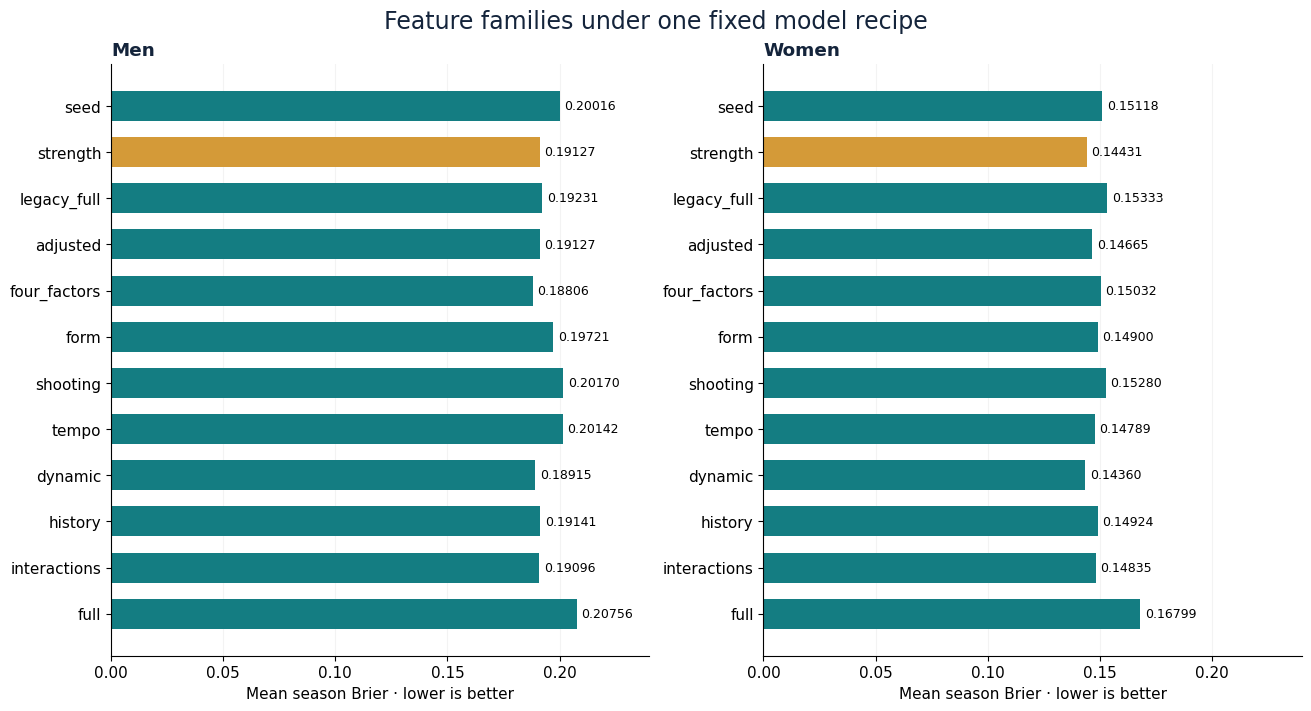

Gender,block,model,macro_season_brier,log_loss,roc_auc,ece_10_bins,games
M,four_factors,logistic,0.188058,0.552180,0.791017,0.059303,334
M,dynamic,logistic,0.189147,0.554157,0.786797,0.055422,334
M,interactions,logistic,0.190964,0.558328,0.783766,0.052524,334
M,strength,logistic,0.191268,0.558170,0.782395,0.048857,334
M,adjusted,logistic,0.191268,0.558799,0.781205,0.048271,334
W,dynamic,logistic,0.143597,0.429754,0.879182,0.084778,315
W,strength,logistic,0.144308,0.433855,0.876280,0.060591,315
W,adjusted,logistic,0.146648,0.440243,0.872571,0.048515,315
W,tempo,logistic,0.147893,0.443700,0.868580,0.044854,315
W,interactions,logistic,0.148348,0.443893,0.870394,0.048522,315


In [5]:
if RESULTS is not None:
    leaderboard = pd.read_csv(RESULTS / "leaderboard.csv")
    shown = leaderboard.query("model == 'logistic'")
    shown = shown.loc[~shown.block.str.startswith("without_")]
    order = ["seed", "strength", "legacy_full", "adjusted", "four_factors", "form", "shooting", "tempo", "dynamic", "history", "rankings", "interactions", "full"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharex=True, constrained_layout=True)
    for ax, gender, title in zip(axes, ['M', 'W'], ['Men', 'Women']):
        panel = shown.loc[shown.Gender.eq(gender)].set_index('block').reindex(order).dropna(subset=['macro_season_brier'])
        colors = ['#d49a38' if name == 'strength' else '#147d82' for name in panel.index]
        ax.barh(panel.index, panel.macro_season_brier, color=colors, height=.65)
        ax.invert_yaxis()
        ax.set_title(title, loc='left', color='#14243b')
        ax.set_xlabel('Mean season Brier · lower is better')
        ax.set_xlim(0, max(.24, shown.macro_season_brier.max() + .03))
        ax.grid(axis='x', alpha=.15)
        ax.set_axisbelow(True)
        for i, value in enumerate(panel.macro_season_brier):
            ax.text(value + .002, i, f'{value:.5f}', va='center', fontsize=9)
    fig.suptitle('Feature families under one fixed model recipe', fontsize=17, color='#14243b')
    display(fig)
    plt.close(fig)
    table(leaderboard.sort_values(['Gender', 'macro_season_brier']).groupby('Gender').head(5)
          [['Gender','block','model','macro_season_brier','log_loss','roc_auc','ece_10_bins','games']])

## Uncertainty and honest interpretation

Negative changes favor the added family. Intervals resample whole seasons to preserve within-season dependence. There are only five development seasons and many comparisons: these intervals are exploratory, and an observed winner is not an independently validated improvement.

The earlier men's system reports 0.180669 and the earlier women's system 0.148684 on this season set. Their original game-level forecasts are still needed for an exact paired comparison. Those scores and the single-season Kaggle score are different quantities.

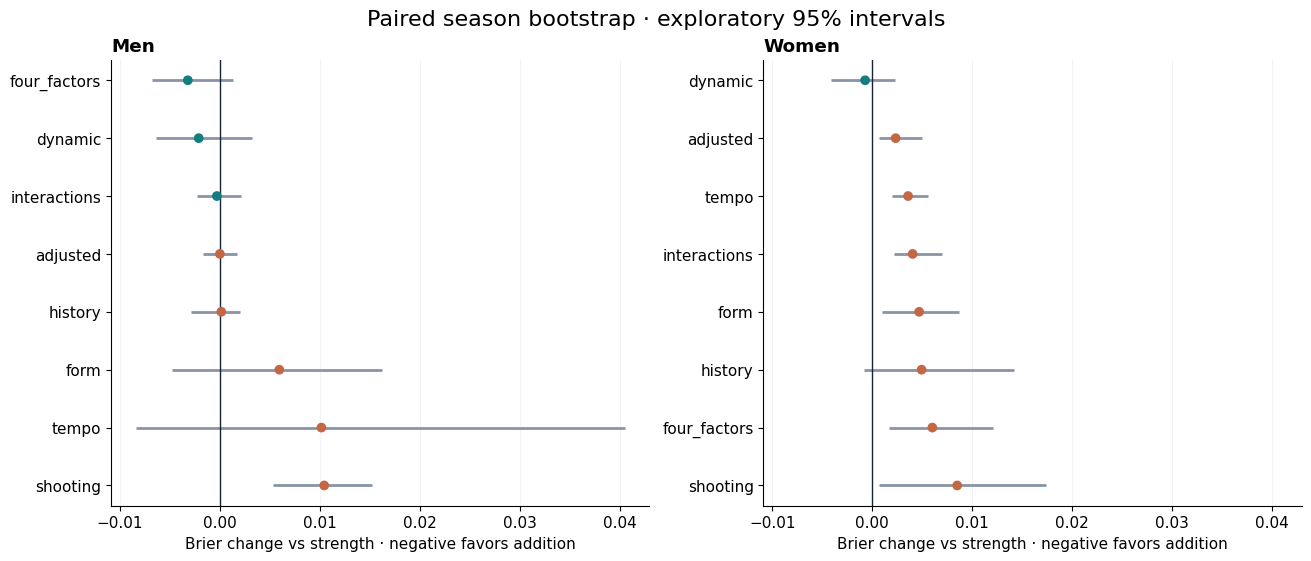

**Completed fold tasks:** 400. **Run elapsed time:** 81.3 seconds. No automatic promotion or Kaggle submission.

In [6]:
if RESULTS is not None:
    intervals = pd.read_csv(RESULTS / 'ablation_intervals.csv')
    additions = intervals.query("model == 'logistic' and baseline == 'strength'")
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, constrained_layout=True)
    for ax, gender, title in zip(axes, ['M','W'], ['Men','Women']):
        panel = additions.loc[additions.Gender.eq(gender)].sort_values('brier_delta')
        y = np.arange(len(panel))
        ax.hlines(y, panel.ci_low, panel.ci_high, color='#8995a6', linewidth=2)
        ax.scatter(panel.brier_delta, y, color=['#147d82' if v < 0 else '#c36745' for v in panel.brier_delta], zorder=3)
        ax.set_yticks(y, panel.candidate)
        ax.invert_yaxis()
        ax.axvline(0, color='#14243b', linewidth=1)
        ax.set_title(title, loc='left')
        ax.set_xlabel('Brier change vs strength · negative favors addition')
        ax.grid(axis='x', alpha=.15)
    fig.suptitle('Paired season bootstrap · exploratory 95% intervals', fontsize=16)
    display(fig)
    plt.close(fig)
    display(Markdown(f"**Completed fold tasks:** {SUMMARY['fold_tasks']}. **Run elapsed time:** {SUMMARY['elapsed_seconds']:.1f} seconds. No automatic promotion or Kaggle submission."))

## Run, resume and review

Use the existing AWS Studio terminal:

```bash
git pull --ff-only
python3 scripts/bootstrap.py
.venv/bin/march-data --output data/kaggle \
  --s3 s3://sagemaker-march-mania-560403859723-us-west-2/data
.venv/bin/march-features --raw data/kaggle/raw \
  --output outputs/feature_store \
  --s3 s3://sagemaker-march-mania-560403859723-us-west-2/feature-store
```

Repeat the same commands after interruption. Completed files, season snapshots and model folds are checksum-verified and reused. Events include UTC, total elapsed time, task timing and a heartbeat. Changed inputs or code require a new run directory.

Then select **Run All** in this notebook. Open `outputs/feature_store/report.html` for interactive charts. `feature_registry.csv`, `diagnostics.csv`, `predictions.parquet` and the per-fold manifests expose the supporting evidence.

The next stage is to migrate notebook 03's nested model tuning and calibration to this contract, compare retained models on identical IDs, and freeze the final recipe. The Stage 2 feature matrix preserves official sample order when that file is available; final probabilities and submission validation follow model selection. The 2026 event is already completed, so new work on its outcomes is retrospective.

[Detailed run guide and definitions](../docs/feature_store.md) · [Notebook 05 evidence](05_feature_research.ipynb)